# 04. Customer Clustering (Phân cụm Khách hàng)

**Mục tiêu:**
- Sử dụng dữ liệu RFM để phân nhóm khách hàng bằng nhiều thuật toán.
- So sánh các thuật toán: K-Means, GMM, Agglomerative Clustering, DBSCAN.
- Đánh giá bằng các metric: Silhouette Score, Davies-Bouldin, Calinski-Harabasz, và Dunn Index (sử dụng Dunn Approximation).
- Lưu lại mô hình và gán tên nhóm (Business Segment) cho khách hàng.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from src.config import PROCESSED_DIR, TABLES_CLUSTERING, MODELS_CLUSTERING_DIR, FIGURES_CLUSTERING
from src.clustering import (
    prepare_clustering_features, run_kmeans, run_gmm, run_agglomerative, run_dbscan,
    build_comparison_table, select_best_model, create_cluster_profiles, assign_business_names,
    save_clustering_results, pca_2d
)
from src.visualization import (
    plot_elbow_curve, plot_silhouette_comparison, plot_metrics_comparison,
    plot_cluster_distribution, plot_cluster_rfm_boxplots, plot_pca_2d, plot_rfm_heatmap
)

# Render biểu đồ trực tiếp trong cell output
%matplotlib inline

## 1. Chuẩn bị Dữ liệu
- Load features RFM.
- Chuyển đổi theo pipeline: `RFM -> log1p -> StandardScaler`.
- Kiểm tra missing, duplicate, và giá trị âm.

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'rfm_clustering_features.csv')
print(f"Số lượng khách hàng: {len(df):,}")

# Validate data
assert df['CustomerID'].isnull().sum() == 0, 'Missing CustomerID'
assert df['CustomerID'].duplicated().sum() == 0, 'Duplicate CustomerID'
assert (df['Recency'] >= 0).all() and (df['Frequency'] >= 1).all() and (df['Monetary'] > 0).all(), 'Invalid RFM values'

rfm_cols = ['Recency', 'Frequency', 'Monetary']
X_raw, X_log, X_scaled, scaler, feature_names, customer_ids = prepare_clustering_features(df, rfm_cols)

print("\nThống kê mô tả dữ liệu gốc (RFM):")
display(df[rfm_cols].describe())

Số lượng khách hàng: 4,334

Thống kê mô tả dữ liệu gốc (RFM):


,Recency,Frequency,Monetary
count,4334.000000,4334.000000,4334.000000
mean,92.703046,4.245962,2015.973153
std,100.177047,7.634989,8903.673825
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,304.240000
50%,51.000000,2.000000,662.565000
75%,143.000000,5.000000,1631.622500
max,374.000000,206.000000,279138.020000


## 2. So sánh Thuật toán
Thực thi vòng lặp qua K-Means, GMM, Agglomerative (với K từ 2 đến 8) và DBSCAN (nhiều cấu hình eps/min_samples).

In [3]:
k_range = range(2, 9)
all_results = []
kmeans_results = []

for k in k_range:
    labels, model, metrics = run_kmeans(X_scaled, k)
    kmeans_results.append(('K-Means', k, labels, model, metrics))
    all_results.append(('K-Means', k, labels, model, metrics))

for k in k_range:
    labels, model, metrics = run_gmm(X_scaled, k)
    all_results.append(('GMM', k, labels, model, metrics))

for k in k_range:
    labels, model, metrics = run_agglomerative(X_scaled, k, linkage='ward')
    all_results.append(('Agglomerative(ward)', k, labels, model, metrics))

dbscan_configs = [(0.3, 5), (0.5, 5), (0.7, 5), (1.0, 5), (0.5, 10)]
for eps, min_s in dbscan_configs:
    labels, model, metrics = run_dbscan(X_scaled, eps=eps, min_samples=min_s)
    all_results.append(('DBSCAN', metrics['n_clusters'], labels, model, metrics))

comparison_df = build_comparison_table(all_results)
display(comparison_df.sort_values('silhouette_score', ascending=False).head(10))

,algorithm,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,dunn_approximation,noise_ratio,min_cluster_size,max_cluster_pct,runtime_seconds,is_selected
23,"DBSCAN(eps=0.7,min=5)",2,0.5659,0.3483,49.9624,0.4770,0.55,5,99.33,0.2580,False
0,K-Means,2,0.4330,0.8917,4364.6091,0.2093,0.00,1662,61.65,0.1761,False
14,Agglomerative(ward),2,0.4232,0.9064,4227.3723,0.2048,0.00,1726,60.18,0.7170,False
2,K-Means,4,0.3381,1.0131,3329.6842,0.1506,0.00,686,37.75,0.0722,False
1,K-Means,3,0.3375,1.0462,3626.2766,0.1669,0.00,763,43.22,0.0512,False
3,K-Means,5,0.3172,0.9851,3194.6602,0.1786,0.00,312,27.57,0.0825,False
15,Agglomerative(ward),3,0.3146,1.1509,3040.2604,0.1694,0.00,633,60.18,0.7681,False
4,K-Means,6,0.3141,1.0106,3083.6138,0.1630,0.00,317,22.82,0.0928,False
5,K-Means,7,0.3095,0.9692,2960.3706,0.1719,0.00,219,20.51,0.1295,False
6,K-Means,8,0.3012,0.9944,2824.3335,0.1525,0.00,214,19.54,0.1114,False


## 3. Trực quan hóa So sánh Metric
Sinh biểu đồ live để đánh giá xu hướng Silhouette Score, Davies-Bouldin, Calinski-Harabasz và Dunn Approximation.

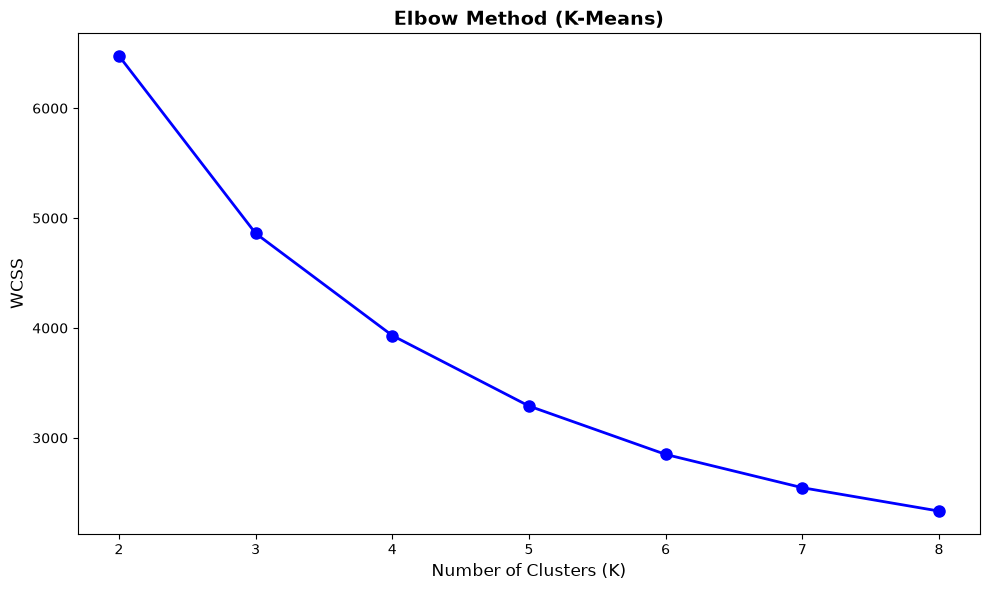

In [4]:
plot_elbow_curve(kmeans_results)

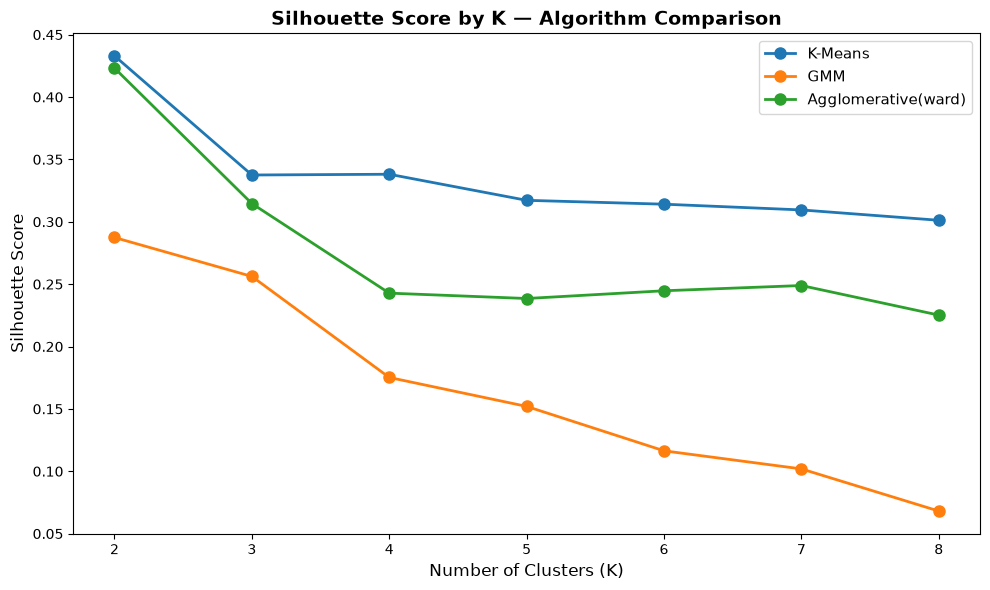

In [5]:
plot_silhouette_comparison(comparison_df, k_range)

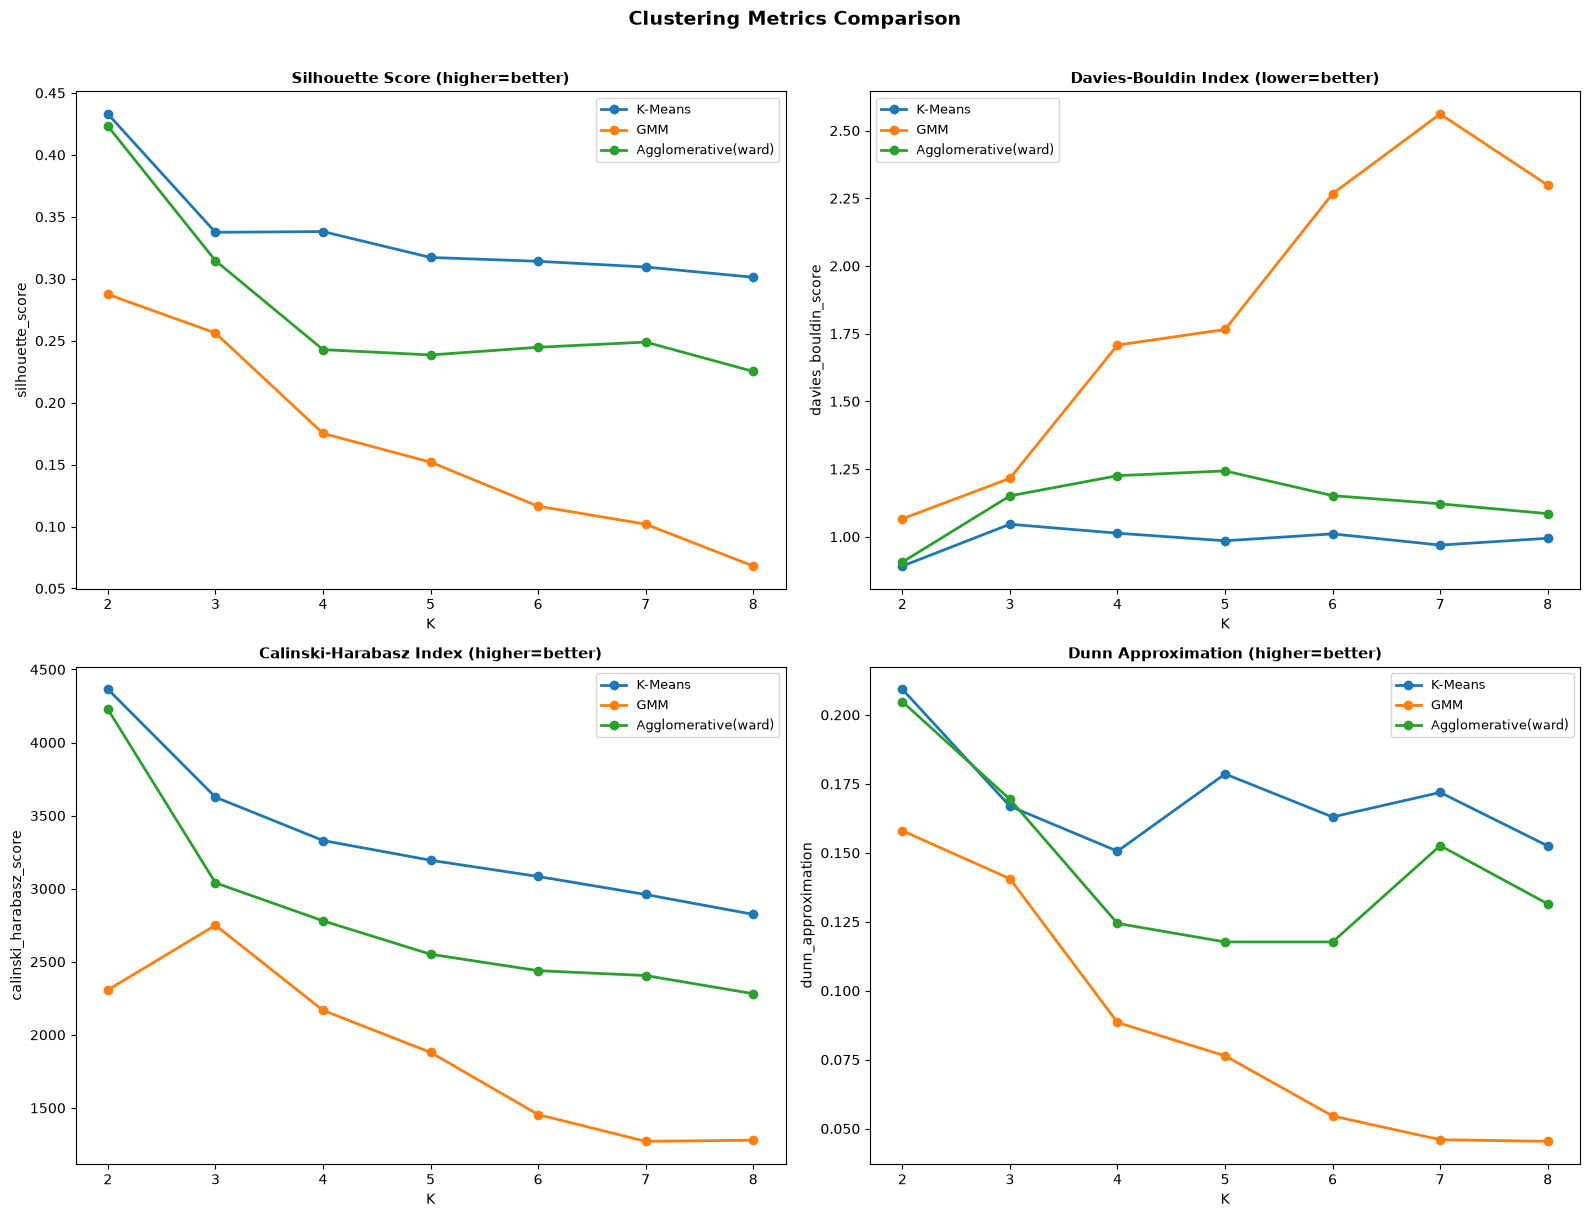

In [6]:
plot_metrics_comparison(comparison_df, k_range)

## 4. Lựa chọn Mô hình & Phân khúc (Profiles)
- Chọn mô hình có điểm xếp hạng tổng hợp (combined rank) tốt nhất.
- Lọc bỏ các mô hình có ít hơn 2 cụm, cụm quá bé (<10) hoặc 1 cụm quá lớn (>90%).

In [7]:
best_labels, best_model, best_metrics = select_best_model(all_results, comparison_df)
best_algo = best_metrics['algorithm']
best_k = best_metrics['n_clusters']

print(f"Thuật toán được chọn: {best_algo} (K={best_k})")
print(f"Silhouette Score: {best_metrics['silhouette_score']:.4f}")
print(f"Davies-Bouldin Index: {best_metrics['davies_bouldin_score']:.4f}")
print(f"Calinski-Harabasz: {best_metrics['calinski_harabasz_score']:.1f}")
print(f"Dunn Approximation: {best_metrics['dunn_approximation']:.4f}")

profiles = create_cluster_profiles(df, best_labels, rfm_cols)
profiles = assign_business_names(profiles)
name_map = dict(zip(profiles['Cluster'].astype(int), profiles['BusinessName']))

display(profiles)

Thuật toán được chọn: K-Means (K=2)
Silhouette Score: 0.4330
Davies-Bouldin Index: 0.8917
Calinski-Harabasz: 4364.6
Dunn Approximation: 0.2093


,Cluster,CustomerCount,CustomerPercentage,MeanRecency,MedianRecency,MeanFrequency,MedianFrequency,MeanMonetary,MedianMonetary,TotalMonetary,BusinessName
0,0,1662,38.35,25.82,16.0,8.40,6.0,4464.19,2041.33,7419490.14,Best Customers
1,1,2672,61.65,134.30,96.0,1.66,1.0,493.17,356.92,1317737.50,Lost Customers


## 5. Trực quan hóa Khách hàng & Lưu kết quả

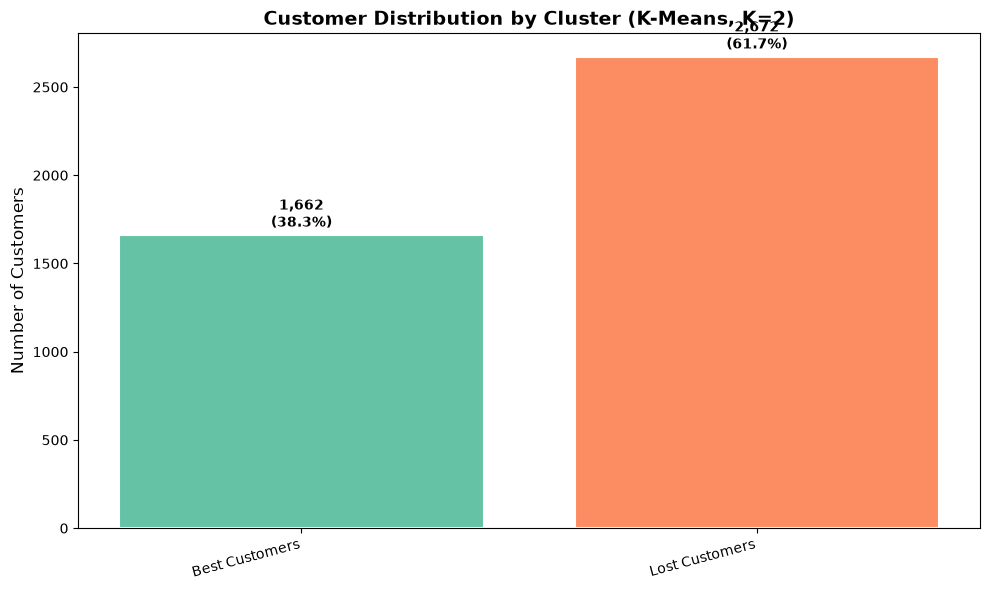

In [8]:
plot_cluster_distribution(best_labels, len(df), name_map, best_algo, best_k)

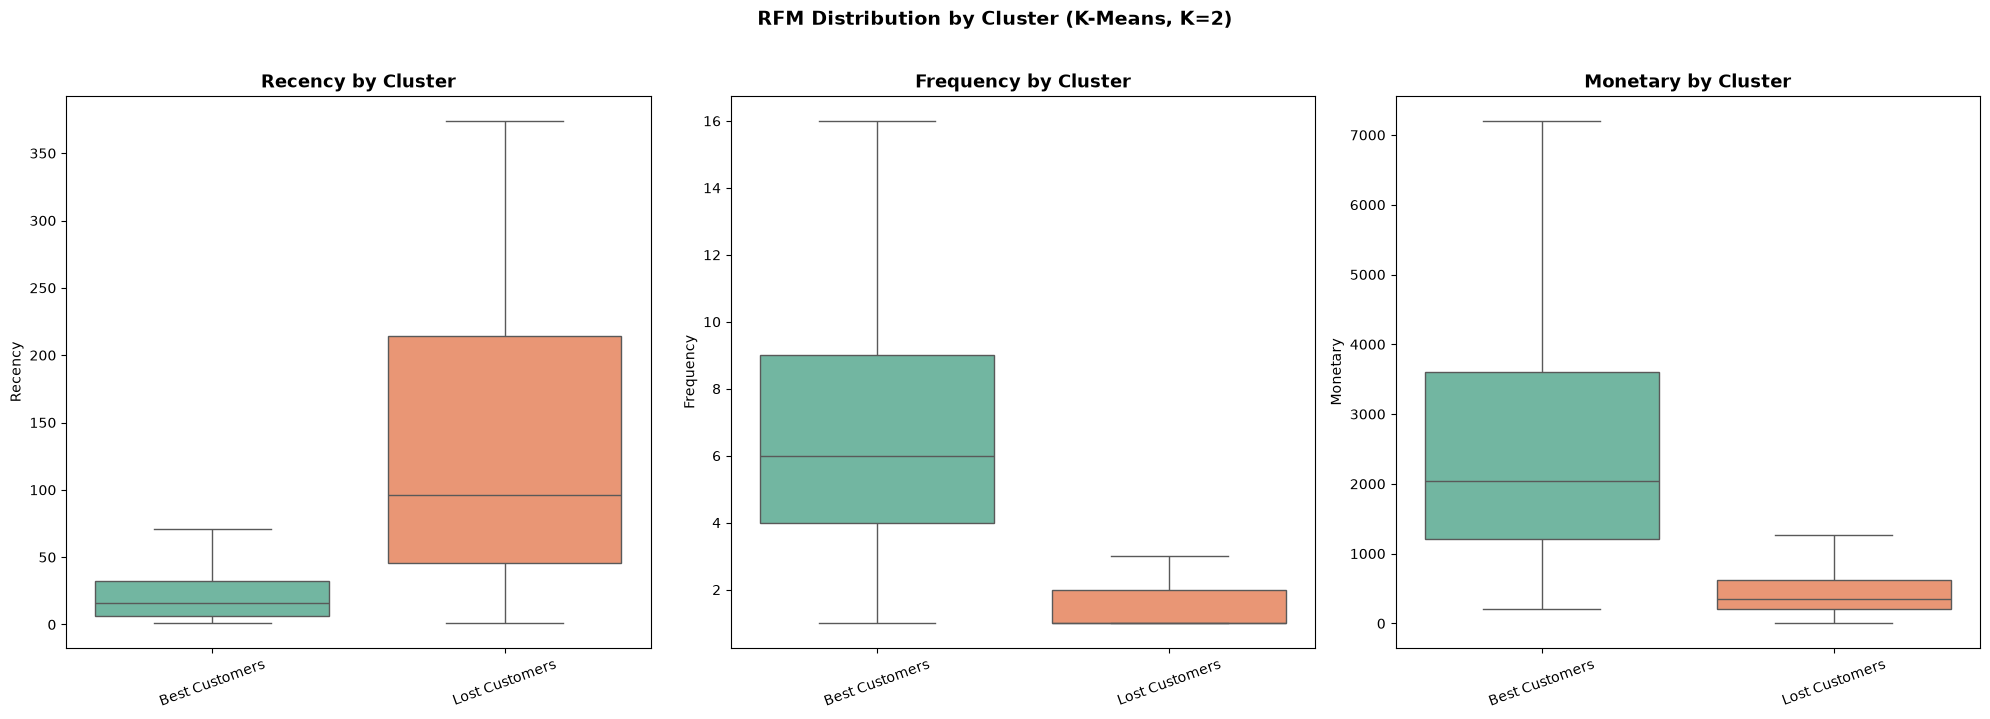

In [9]:
plot_cluster_rfm_boxplots(df, best_labels, name_map, rfm_cols, best_algo, best_k)

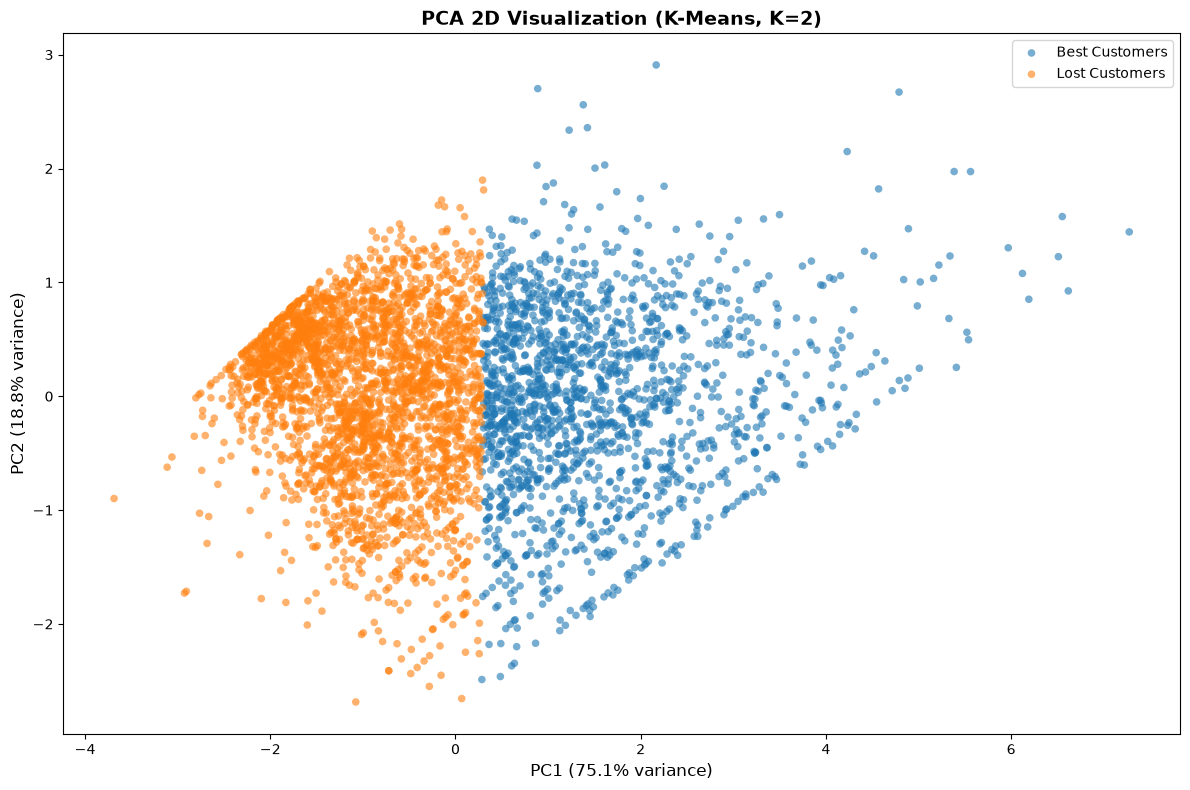

In [10]:
pca_df, pca_model = pca_2d(X_scaled, best_labels)
plot_pca_2d(pca_df, pca_model, name_map, best_algo, best_k)

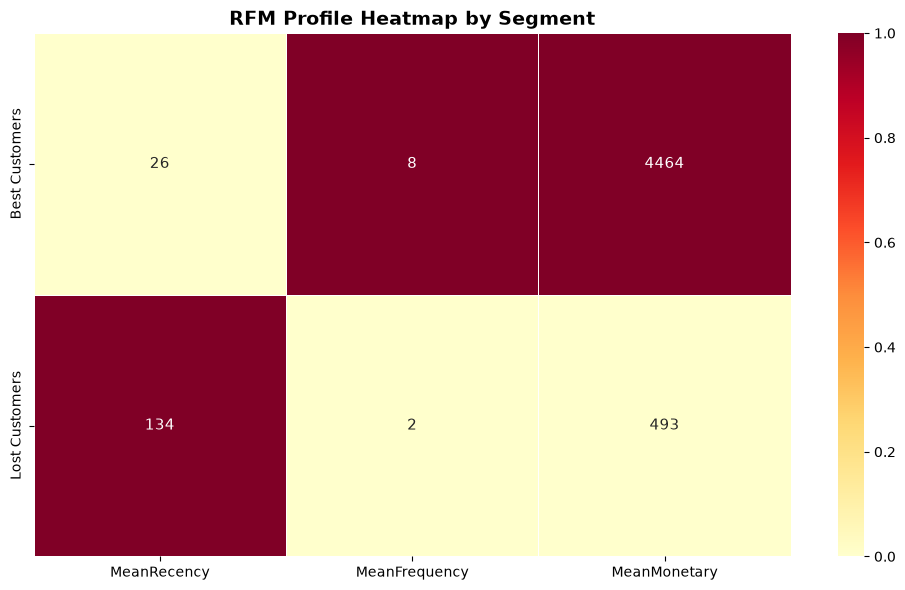

In [11]:
plot_rfm_heatmap(profiles, best_k)

In [12]:
# Save outputs matching runner exact process
comparison_df.to_csv(TABLES_CLUSTERING / 'clustering_algorithm_comparison.csv', index=False)
profiles.to_csv(TABLES_CLUSTERING / 'cluster_profiles.csv', index=False)

df_result = df[['CustomerID'] + rfm_cols].copy()
df_result['Cluster'] = best_labels
df_result['Algorithm'] = best_algo
df_result['FeatureVersion'] = 'log1p_scaled'
df_result['BusinessSegment'] = df_result['Cluster'].map(name_map)
df_result.to_csv(PROCESSED_DIR / 'customer_clusters.csv', index=False)

config = {
    'algorithm': best_algo, 'n_clusters': best_k, 'feature_names': feature_names,
    'feature_version': 'log1p_scaled', 'metrics': best_metrics, 'n_customers': len(df)
}
save_clustering_results(best_model, scaler, best_labels, config, MODELS_CLUSTERING_DIR)
print("Saved all results successfully.")

  [OK] Model saved to D:\Project\Data-mininng\models\clustering
Saved all results successfully.
